# The Volatility Risk Premium and the Leverage Effect in Crypto Options
### What we measured, what we found, and why almost all of it is zero

**Natixis CIB — Quant Analyst Internship**

---

This notebook is the companion to `project_outline.ipynb`. That one documents the
**surface-fitting library**: how to clean Deribit quotes, calibrate SVI/SSVI/eSSVI/SABR,
check static arbitrage, and serve a live screen. This one documents the **research
programme built on top of it** — an attempt to find a harvestable volatility risk
premium in ETH options, and the measurement work that came out of failing to.

The honest summary in one line: **we found one real effect and a catalogue of
well-measured zeros.** That is a result, and this notebook is written to make the zeros
as legible as the positive.

By the end you will be able to:

1. Read the volatility risk premium on ETH and see why it is not tradeable.
2. Compare four realised-volatility estimators and quantify the **discretisation loss** —
   the variation a discretely hedged position never monetises.
3. Recognise the two parameter traps that cost the most time on this project
   (bars-vs-days, and correlation-window sample size).
4. Audit a research pipeline for look-ahead, and find the one contaminated input we had.
5. Calibrate an estimator by Monte Carlo *before* interpreting it — the step that changed
   the conclusion.
6. State ETH's leverage effect with a defensible number and an honest confidence interval.

> **Runtime note.** Around **90 seconds** end to end. The Monte Carlo in section 5 is the
> slowest cell (~20 s). Sections that need the full options archive are marked
> **[archive]** and are reported from recorded results rather than recomputed — that file
> lives on the desk machine, not here.

## Table of contents

0. [Environment setup](#sec0)
1. [The question, and why it resisted](#sec1)
2. [Realised volatility: four estimators and the discretisation loss](#sec2)
3. [The spot–vol correlation: two parameter traps](#sec3)
4. [Data audit, and one contaminated input](#sec4)
5. [Monte Carlo: what the pipeline can actually see](#sec5)
6. [The leverage effect, properly measured](#sec6)
7. [The volatility risk premium: nothing to harvest](#sec7)
8. [Trials & errors](#sec8)
9. [Conclusion: a catalogue of well-measured zeros](#sec9)

<a id="sec0"></a>
## 0. Environment setup

Everything below runs from the perp alone — 1-minute ETH perpetual bars, June 2024 to
August 2026. The options archive used in section 7 is not on this machine.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True,
                     "grid.alpha": 0.3, "figure.dpi": 110})

here = Path.cwd()
PROJECT_ROOT = next((p for p in [here, *here.parents] if (p / "2 - Data").exists()), here)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

PERP    = str(PROJECT_ROOT / "2 - Data" / "parquets" / "eth_perp_1min_2024_2026.parquet")
RESULTS = PROJECT_ROOT / "results"
print("perp exists    :", Path(PERP).exists())
print("results/ exists:", RESULTS.exists())

Project root: /Users/macbookair/Internship Natixis
perp exists    : True
results/ exists: True


In [2]:
from volatility_surface.backtest import leverage as LEV
from volatility_surface.backtest import spot_vol_corr as SV
from volatility_surface.backtest import vrp_signal as V
from volatility_surface.backtest import roll_engine as R
from volatility_surface.plots.vol_plots import PALETTE

print("realised-vol estimators :", V.ESTIMATORS)
print("hand-labelled regimes   :", list(R.REGIMES))
print("random seed             :", LEV.SEED)

realised-vol estimators : ('close', 'parkinson', 'garman_klass', 'rogers_satchell')
hand-labelled regimes   : ['bear1', 'bear2', 'bear3', 'bull1', 'bull2']
random seed             : 20260810


<a id="sec1"></a>
## 1. The question, and why it resisted

The starting point was Lucic & Sepp (2024): delta-hedged option structures on crypto,
rolled systematically. The theoretical case is the **volatility risk premium** — implied
vol usually exceeds subsequent realised vol, so selling vol and hedging the delta should
earn the difference.

We replicated the strategy family on ETH and BTC Deribit data (2024–2026). **No variant
produced a positive Sharpe.** The rest of the project is the diagnosis, and it turned into
three separate measurement problems:

| # | Question | Section |
|---|---|---|
| 1 | Is the realised vol we measure the one a hedger actually earns? | 2 |
| 2 | Is the spot–vol correlation we measure real, or a parameter artefact? | 3, 4, 5 |
| 3 | Is there a premium to harvest at all? | 7 |

The answers, in order: **no** (there is a 3–6 vol-point gap depending on the estimator),
**mostly artefact until we fixed it** (and the fixed version is real but weak), and
**no** (the premium is −0.82% with a t-statistic of −0.44).

> **Why this notebook exists.** Every one of these was initially mis-measured, and each
> mis-measurement pointed at a different wrong conclusion. The sequencing matters more
> than any single number.

<a id="sec2"></a>
## 2. Realised volatility: four estimators and the discretisation loss

`vrp_signal.perp_variance` implements four per-bar variance estimators. They answer
different questions, and the spread between them is itself the result.

| estimator | reads | measures |
|---|---|---|
| `close` | $\log(c_t/c_{t-1})^2$ | quadratic variation **at the sampling frequency** — what a hedger rebalancing at that frequency earns |
| `parkinson` | $\log(h/l)^2/(4\log 2)$ | latent continuous volatility, from the bar range |
| `garman_klass` | range + $\log(c/o)^2$ | same, more efficient |
| `rogers_satchell` | range + open/close | same, robust to intrabar drift |

`close` is the only one a discretely hedged position actually monetises. The range
estimators see variation happening **inside** the hedging interval. The difference is the
**discretisation loss**.

In [3]:
# One trailing-vol panel per estimator. We call realised_vol_by_estimator directly
# rather than SV.build: build() needs the options archive to define its snapshot grid,
# and for a levels chart a dense daily grid off the perp is both denser and honest.
perp = pd.read_parquet(PERP, columns=["timestamp_ms", "close"])
perp.index = pd.to_datetime(perp["timestamp_ms"], unit="ms", utc=True)
spot = perp["close"].resample("1D").last().dropna()

rv14 = SV.realised_vol_by_estimator(PERP, spot.index, V.ESTIMATORS,
                                    window_days=14, bar_freq="1h")
panel = rv14.copy()
panel["spot"] = spot
panel.attrs.update(rv_window=14, bar_freq="1h")
panel = panel.dropna(subset=["spot"])

tbl = SV.levels(panel)
print("Annualised vol, 14-day trailing window on 1h bars (vol points)")
tbl

Annualised vol, 14-day trailing window on 1h bars (vol points)


,n,mean,median,min,max,std,vs_close
series,,,,,,,
rv_close,793,64.60,62.87,25.08,116.00,17.85,0.00
rv_parkinson,794,67.75,64.82,23.26,128.22,20.12,3.14
rv_garman_klass,794,68.90,65.74,24.32,134.16,21.07,4.30
rv_rogers_satchell,794,70.66,66.74,24.65,146.16,22.68,6.06


`vs_close` is the discretisation loss. Read it as: **an hourly hedger on ETH gives up
3 to 6 vol points** of variation that the underlying genuinely realised but that never
appears between rebalances.

The loss is **not a constant offset** — it is near zero when vol is ~50% and reaches
~15 points at the peaks.

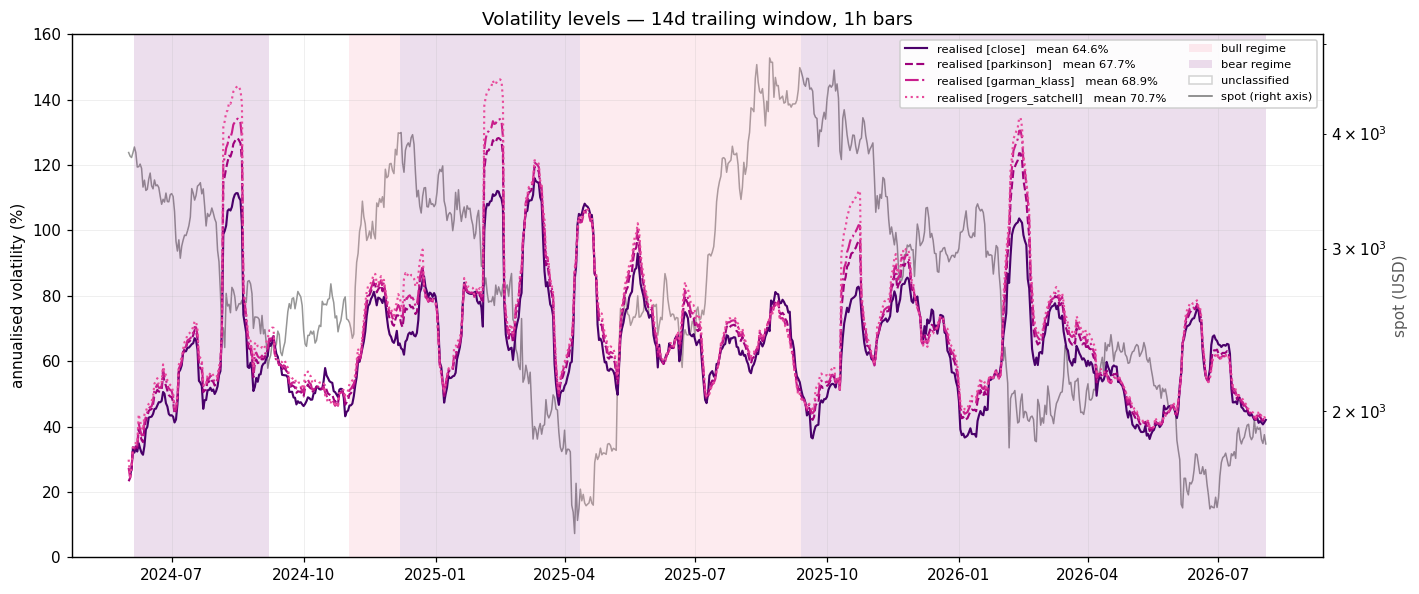

In [4]:
SV.plot_levels(panel, regimes=R.REGIMES, log_spot=True, implied=False, ylim=(0, 160))

> **Trial & error.** Our first version of this chart used `rv_window=1`, which produced a
> solid picket fence between 20% and 120% and was unreadable. Clipping the axis did not
> help. The cause was not the axis but the estimator: a 1-day window on hourly bars is
> 24 observations, carrying **29% relative standard error**. Raising the window to 14 days
> (336 bars, 8% s.e.) fixed it. Levels and correlations want *different* windows —
> see section 3.

<a id="sec3"></a>
## 3. The spot–vol correlation: two parameter traps

This section is here because it consumed more time than any other part of the project,
and both traps are the kind that produce a plausible-looking wrong answer rather than an
error message.

### Trap 1 — a window that changed units

`spot_vol_corr.build(rv_window=...)` originally took a **count of bars**. It was later
changed to **calendar days**. Same argument name, same call site, different meaning:

```python
# before:  rolling(90) on a daily frame  -> 90 observations ~ 90 days
# after :  rolling("90D") on hourly bars -> 90 days = 2160 bars
```

A measured correlation moved from **−0.02 to −0.18** with nothing else altered. Neither
number was wrong; they were answers to different questions.

### Trap 2 — a correlation window too short to resolve the effect

`rolling(window_days=n)` sets the **sample size of each estimate**, not what is measured.
The smallest correlation distinguishable from zero at $p<0.05$:

| n | smallest detectable \|ρ\| |
|---|---|
| 5 | 0.88 |
| 30 | 0.36 |
| 90 | 0.21 |
| 180 | 0.15 |

We were hunting an effect of ~0.2 with `n=5` at one point, which returns ±1 noise by
construction. **Below n≈90 this effect cannot be resolved at all.**

In [5]:
# Trap 2, measured: the sawtooth is caused by window_days, not by rv_window.
rows = []
for w in (1, 5, 30):
    rv = SV.realised_vol_by_estimator(PERP, spot.index, ("close",), w, "1h")["rv_close"]
    d = rv.diff()
    ret = np.log(spot / spot.shift(1))
    for rw in (5, 30, 90, 180):
        rc = ret.rolling(rw).corr(d).dropna()
        rows.append({"rv_window": w, "window_days": rw, "std": rc.std(),
                     "share |corr|>0.9": float((rc.abs() > 0.9).mean()),
                     "min": rc.min(), "max": rc.max()})
pd.DataFrame(rows).set_index(["rv_window", "window_days"]).round(3)

std  share |corr|>0.9    min    max
rv_window window_days                                       
1         5            0.491             0.034 -0.989  0.989
          30           0.210             0.000 -0.483  0.431
          90           0.139             0.000 -0.311  0.233
          180          0.091             0.000 -0.245  0.100
5         5            0.473             0.027 -0.980  0.989
          30           0.158             0.000 -0.421  0.502
          90           0.083             0.000 -0.218  0.226
          180          0.043             0.000 -0.123  0.109
30        5            0.493             0.051 -0.985  0.976
          30           0.195             0.000 -0.642  0.562
          90           0.108             0.000 -0.340  0.208
          180          0.068             0.000 -0.160  0.071

Every `window_days=5` row hits ±0.98 regardless of `rv_window`. The instability is
entirely the correlation window.

### The overlap trade-off

There is no free choice of `rv_window`. Short windows remove overlap between consecutive
observations but add estimation noise; long windows do the reverse.

In [6]:
rows = []
for w in (1, 3, 7, 14, 30):
    rv = SV.realised_vol_by_estimator(PERP, spot.index, ("close",), w, "1h")["rv_close"]
    nb = 24 * w
    rows.append({"rv_window": w, "bars/obs": nb,
                 "rel. s.e.": f"{100*np.sqrt(2/nb):.0f}%",
                 "hours shared": max(0, nb - 24),
                 "ac1(level)": rv.autocorr(1), "ac1(diff)": rv.diff().autocorr(1),
                 "eff. obs in a 90-window": 90 / w})
pd.DataFrame(rows).set_index("rv_window").round(3)

,bars/obs,rel. s.e.,hours shared,ac1(level),ac1(diff),eff. obs in a 90-window
rv_window,,,,,,
1,24,29%,0,0.424,-0.348,90.000
3,72,17%,48,0.850,0.228,30.000
7,168,11%,144,0.951,0.306,12.857
14,336,8%,312,0.978,0.343,6.429
30,720,5%,696,0.991,0.265,3.000


At `rv_window=30` a 90-observation rolling correlation rests on roughly **3 independent
observations**. That is the staircase we spent a session interpreting as a signal.

Note the `ac1(diff)` column: **negative at `rv_window=1`, positive from 3 upward**. That is
the signature of non-overlap, and it matters in section 5.

<a id="sec4"></a>
## 4. Data audit, and one contaminated input

Before trusting any conditional statistic, we audited the inputs. The perp data came out
unusually clean; one derived input did not.

In [7]:
d = pd.read_parquet(PERP)
d.index = pd.to_datetime(d["timestamp_ms"], unit="ms", utc=True)
span = d.index.max() - d.index.min()
expected = int(span.total_seconds() / 60) + 1
gaps = d.index.to_series().diff()

audit = pd.Series({
    "1-min bars":              f"{len(d):,}",
    "expected bars":           f"{expected:,}",
    "missing":                 f"{expected - len(d):,}",
    "duplicated timestamps":   int(d["timestamp_ms"].duplicated().sum()),
    "gaps > 5 min":            int((gaps > pd.Timedelta('5min')).sum()),
    "span (days)":             f"{span.total_seconds()/86400:.1f}",
    "zero-range bars":         f"{(d['high']==d['low']).sum():,} ({(d['high']==d['low']).mean():.2%})",
    "zero-volume bars":        f"{(d['volume']==0).sum():,} ({(d['volume']==0).mean():.2%})",
    "OHLC violations":         int((d['high'] < d['low']).sum()),
}, name="value")
audit.to_frame()

,value
1-min bars,"1,142,674"
expected bars,"1,142,674"
missing,0
duplicated timestamps,0
gaps > 5 min,0
span (days),793.5
zero-range bars,"86,439 (7.56%)"
zero-volume bars,"30,898 (2.70%)"
OHLC violations,0


Zero missing minutes over 793.5 days. The 7.6% zero-range bars are thin minutes where a
single price traded, not corrupt data.

### Liquidation wicks — the range estimators' exposure

In [8]:
body = (d["close"] - d["open"]).abs()
ratio = ((d["high"] - d["low"]) / body.replace(0, np.nan)).dropna()
print("(high-low)/|close-open| quantiles")
print(ratio.quantile([.5, .9, .99, .999, .9999]).round(2).to_string())
print(f"\ntop 0.1%: {int((ratio > ratio.quantile(.999)).sum()):,} bars")
print("\nfive most extreme single-minute bars:")
d.loc[ratio.nlargest(5).index, ["open", "high", "low", "close"]].assign(
    ratio=ratio.nlargest(5).values).round(2)

(high-low)/|close-open| quantiles
0.5000      1.33
0.9000      5.00
0.9900     27.00
0.9990     77.00
0.9999    150.21

top 0.1%: 1,034 bars

five most extreme single-minute bars:


,open,high,low,close,ratio
timestamp_ms,,,,,
2025-10-10 21:49:00+00:00,3799.90,3856.15,3781.45,3800.00,747.00
2025-03-02 16:41:00+00:00,2410.95,2418.25,2388.55,2411.00,594.00
2025-10-10 21:02:00+00:00,3895.05,3904.70,3880.00,3895.10,494.00
2025-02-02 22:41:00+00:00,2806.40,2809.90,2742.65,2806.55,448.33
2025-10-11 01:47:00+00:00,3762.20,3778.55,3761.15,3762.15,348.00


**Three of the five most extreme minutes in two years fall on 2025-10-10/11** — the
October 2025 liquidation cascade. Parkinson/GK/RS all read the high and the low, so these
non-tradeable prints flow straight into them. Section 6 tests whether the headline result
survives dropping them (it does).

### Intraday seasonality

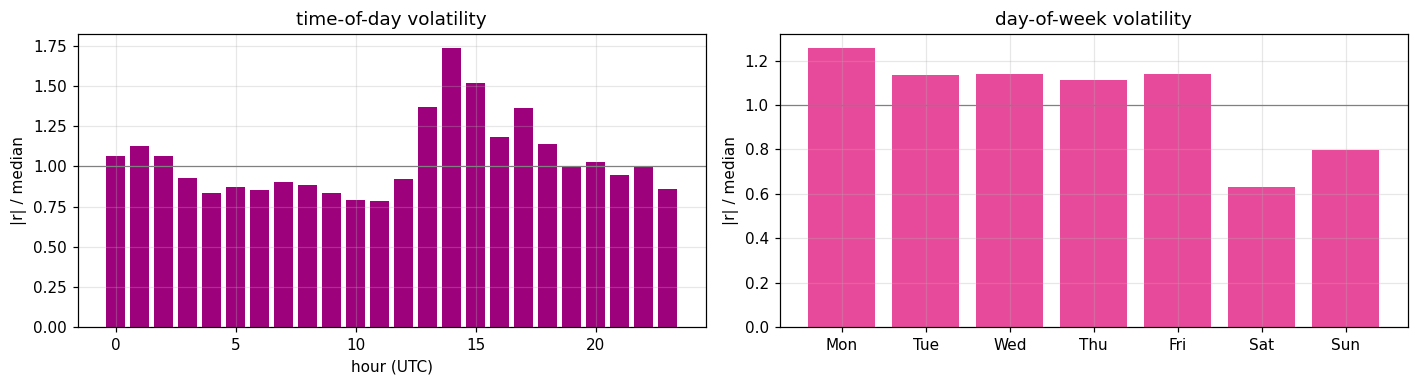

time-of-day amplitude : 2.21x in vol, 4.90x in variance
day-of-week amplitude : 1.99x
ANOVA mean return across hours : F= 1.35  p=0.121   <- not significant
ANOVA |return|    across hours : F=26.04  p=5.4e-110  <- overwhelming


In [9]:
r1h = np.log(d["close"].resample("1h").last().ffill()).diff().dropna()
a = r1h.to_frame("r"); a["hour"] = a.index.hour; a["dow"] = a.index.dayofweek
tod = a.groupby("hour")["r"].apply(lambda x: x.abs().median()) / a["r"].abs().median()
dow = a.groupby("dow")["r"].apply(lambda x: x.abs().median()) / a["r"].abs().median()

from scipy import stats
F_mean, p_mean = stats.f_oneway(*[g["r"].values for _, g in a.groupby("hour")])
F_abs,  p_abs  = stats.f_oneway(*[np.abs(g["r"].values) for _, g in a.groupby("hour")])

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].bar(tod.index, tod.values, color=PALETTE[5]); ax[0].axhline(1, color="grey", lw=.8)
ax[0].set(xlabel="hour (UTC)", ylabel="|r| / median", title="time-of-day volatility")
ax[1].bar(range(7), dow.values, color=PALETTE[3]); ax[1].axhline(1, color="grey", lw=.8)
ax[1].set_xticks(range(7)); ax[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
ax[1].set(ylabel="|r| / median", title="day-of-week volatility")
plt.tight_layout(); plt.show()

print(f"time-of-day amplitude : {tod.max()/tod.min():.2f}x in vol, "
      f"{(tod.max()/tod.min())**2:.2f}x in variance")
print(f"day-of-week amplitude : {dow.max()/dow.min():.2f}x")
print(f"ANOVA mean return across hours : F={F_mean:5.2f}  p={p_mean:.3f}   <- not significant")
print(f"ANOVA |return|    across hours : F={F_abs:5.2f}  p={p_abs:.1e}  <- overwhelming")

Volatility is strongly seasonal (peak 13:00–15:00 UTC, the US cash open); the **mean
return is not**. That asymmetry is fortunate: the classic spurious-correlation mechanism
needs *both* series seasonal. At the daily horizon the seasonality integrates out.

### ⚠️ The contaminated input

`roll_engine.REGIMES` is five hardcoded date ranges. Its own docstring is explicit:

In [10]:
import inspect, re
src = inspect.getsource(R)
block = src[src.index("# Market regimes"):src.index("def _to_ms")]
print(block.strip()[:1100])

# Market regimes
# --------------------------------------------------------------------------- #
#: Hand-labelled ETH regimes over the 2024-2026 dataset, as (start, end) UTC
#: dates. Deliberately NOT derived from the data: the paper's own regime split
#: (Fig 8/9) sorts monthly returns and cuts the tails at 16%, which is circular
#: when the question is "does this strategy survive a regime it did not fit to".
#: These are the user's own reading of the market and are meant to be edited.
#: Note the gaps (e.g. 2024-09-07 -> 2024-11-02) — those months belong to
#: neither camp and are simply excluded from a regime run.
REGIMES: dict[str, tuple[str, str]] = {
    "bear1": ("2024-06-05", "2024-09-07"),
    "bear2": ("2024-12-07", "2025-04-12"),
    "bear3": ("2025-09-13", "2026-08-03"),
    "bull1": ("2024-11-02", "2024-12-07"),
    "bull2": ("2025-04-12", "2025-09-13"),
}


These are **hand-drawn from the finished price chart** — `bear2` runs from a local top to
a local bottom. That is peak-to-trough labelling, which encodes knowledge of the future.

**Consequence: every regime-conditional statistic computed against `R.REGIMES` is
contaminated by hindsight.** They remain useful as *shading* on a chart, which is how this
notebook uses them. For statistics we built a causal replacement — trailing drawdown from
a running max, past information only.

In [11]:
reg_causal = LEV.causal_regimes(spot)
print("causal regime counts (trailing 90-day drawdown from running max):")
print(reg_causal.value_counts().to_string())

causal regime counts (trailing 90-day drawdown from running max):
regime_causal
drawdown     434
neutral      264
near-high     96


<a id="sec5"></a>
## 5. Monte Carlo: what the pipeline can actually see

This is the step that changed the conclusion, and it should have come first.

Before interpreting any empirical correlation, simulate a process with a **known**
spot–vol correlation $\rho = \mathrm{corr}(dW_S, dW_v)$, run the identical estimator over
it, and see what comes back. Heston, 5-minute steps, 794 days to match the real sample,
12 paths per $\rho$.

In [12]:
mc = LEV.mc_recovery(rhos=(-0.8, -0.5, -0.2, 0.0, 0.3), n_days=794,
                     n_paths=12, steps_per_day=288)
mc[["clean_mean", "clean_sd", "clean_lo", "clean_hi",
    "sv_mean", "frac_clean_negative"]].round(4)

,clean_mean,clean_sd,clean_lo,clean_hi,sv_mean,frac_clean_negative
true_rho,,,,,,
-0.8,-0.3069,0.0385,-0.3525,-0.2472,0.0055,1.0000
-0.5,-0.2011,0.0325,-0.2412,-0.1566,0.0016,1.0000
-0.2,-0.0725,0.0341,-0.1232,-0.0308,-0.0013,1.0000
0.0,0.0154,0.0339,-0.0311,0.0622,-0.0015,0.3333
0.3,0.1278,0.0288,0.0759,0.1566,-0.0046,0.0000


Two findings, and the second one overturned a working assumption.

### 5a. The correlation estimator works, but is attenuated ~2.5×

`corr(r_t, Δlog RV_{t+1})` is **monotone in ρ, tight (sd ≈ 0.03), and correctly signed in
100% of paths at every negative ρ tested** — including ρ = −0.2. It passes.

But it is uniformly shrunk toward zero by a factor of ≈ **0.40**. This is intrinsic, not a
bug: daily RV is a noisy estimate of integrated variance, the noise is independent of the
return, and errors-in-variables attenuates any correlation built on it.

**So an observed correlation must be divided by 0.40 to be read as ρ.**

### 5b. Signed variation is blind to a diffusive leverage effect

We had expected $(RS^+ - RS^-)/RV$ — realised semivariance, no correlation coefficient, no
attenuation — to be the cleanest estimand. **The simulation refutes that.** At a true
ρ of −0.8 it reads **+0.0055, the wrong sign**, and it moves by only 0.01 across the whole
range from −0.8 to +0.3 with no monotone ordering.

The reason is structural: in a diffusion, returns are conditionally symmetric given the
current variance level, whatever the correlation between the driving Brownians. Signed
variation therefore detects **asymmetric jumps**, a different economic mechanism.

> **Trial & error, and the lesson of the project.** A null result from signed variation is
> not evidence against a leverage effect. Had we not simulated first, we would have
> reported "no asymmetry in ETH" on the strength of an estimator that cannot see the thing
> we were looking for.

### 5c. Could the rolling correlation have been trusted?

In [13]:
sim = LEV.simulate_heston(-0.7, 794, 288, n_paths=12, seed=7)
share_above, means = [], []
for _, g in sim.groupby("path"):
    g = g.sort_values("day")
    rc = g["ret"].rolling(90).corr(np.log(g["rv"]).diff().shift(-1)).dropna()
    share_above.append(float((rc > 0).mean())); means.append(rc.mean())
print("true rho = -0.70, 90-observation rolling window, 12 paths:")
print(f"  mean rolling correlation          {np.mean(means):+.3f}")
print(f"  share of windows above zero       {np.mean(share_above):.1%}")
print(f"  paths crossing zero at least once {sum(s > 0 for s in share_above)}/12")

true rho = -0.70, 90-observation rolling window, 12 paths:
  mean rolling correlation          -0.280
  share of windows above zero       0.0%
  paths crossing zero at least once 0/12


**A genuinely strong leverage effect would never have produced the near-zero rolling plot
we spent weeks interpreting.** At ρ = −0.7 the rolling estimate sits at −0.28 and does not
touch zero across ~8,400 window-observations.

So the flat plot was **the correct answer to a question asked with too little precision** —
the true value is near −0.21, and at n=90 that is indistinguishable from noise.

<a id="sec6"></a>
## 6. The leverage effect, properly measured

With the estimator calibrated, the measurement. Realised variance is built **per calendar
day from 288 five-minute returns** — non-overlapping, 8.3% relative standard error, no
trailing window.

Three estimands, deliberately kept apart:

| estimand | definition | status |
|---|---|---|
| contaminated | $\mathrm{corr}(r_t, \Delta\log RV_t)$ | $r_t$ sits **inside** $RV_t$ → a realised-skewness estimator |
| clean | $\mathrm{corr}(r_t, \Delta\log RV_{t+1})$ | no mechanical link — the honest correlation proxy |
| LHAR $\gamma_d$ | regression coefficient on $r^-_t$ | controls vol persistence — the literature's primary test |

In [14]:
r5    = LEV.intraday_returns(PERP, "5min")
daily = LEV.daily_measures(r5)
print(f"{len(daily)} days | {int(daily['n_obs'].median())} obs/day | "
      f"mean RV {daily['rv_ann'].mean():.1%} | jumps {(daily['jump']/daily['rv']).mean():.1%} of RV")

e1 = LEV.e1_correlations(daily)
e1[["rho", "n", "n_eff", "boot_lo", "boot_hi", "p_neff"]].round(4)

794 days | 288 obs/day | mean RV 62.3% | jumps 7.7% of RV


,rho,n,n_eff,boot_lo,boot_hi,p_neff
measure,,,,,,
"CONTAMINATED corr(r_t, dlogRV_t) [= skewness]",-0.0932,793,638.1350,-0.1845,-0.0067,0.0182
"CLEAN corr(r_t, dlogRV_t+1)",-0.0851,793,1040.0940,-0.1483,-0.0176,0.0059
"CLEAN corr(r_t, dlogBV_t+1) [jump-robust]",-0.0624,793,1077.8866,-0.1252,0.0075,0.0403
"CLEAN corr(r_t, dlogMedRV_t+1) [jump-robust]",-0.0452,793,1111.8676,-0.1087,0.0252,0.1320


In [15]:
placebo = LEV.placebo_null(daily)
print("Placebo null — returns shuffled, marginals preserved, 2000 replicates:")
print(f"  corr 95% null band  [{placebo['corr_p2.5']:+.4f}, {placebo['corr_p97.5']:+.4f}]")
print(f"  observed clean corr  {e1.loc['CLEAN  corr(r_t, dlogRV_t+1)', 'rho']:+.4f}  <- outside the band")

print("\nE5 signed variation (relabelled: signed JUMP asymmetry, per section 5b):")
LEV.e5_signed_variation(daily).round(5)

Placebo null — returns shuffled, marginals preserved, 2000 replicates:
  corr 95% null band  [-0.0695, +0.0736]
  observed clean corr  -0.0851  <- outside the band

E5 signed variation (relabelled: signed JUMP asymmetry, per section 5b):


,estimate,hac_se,nw_lags,t_stat,p_value,ci_lo,ci_hi,n
measure,,,,,,,,
E5 mean (RS+ - RS-)/RV [per-day],-0.00249,0.00695,6.0,-0.35833,0.72009,-0.01612,0.01113,794
mean realised skewness,-0.01976,0.04749,6.0,-0.41608,0.67735,-0.11283,0.07331,794
pooled (sum RS+ - sum RS-)/sum RV,-0.01548,NaN,NaN,NaN,NaN,NaN,NaN,794


### The primary test — LHAR

$$\log RV_{t+1} = c + \text{HAR}(\log RV) + \gamma_d r^-_t + \gamma_w r^-_{t-4:t}
+ \gamma_m r^-_{t-21:t} + \gamma_p r^+_t$$

In [16]:
lh = LEV.lhar(daily)
print(f"R2 = {lh.attrs['r2']:.4f}   n = {lh.attrs['n']}")
lh.round(4)

R2 = 0.3756   n = 772


,coef,hac_se,t,p,ci_lo,ci_hi
const,-2.4433,0.5054,-4.8345,0.0000,-3.4339,-1.4528
lv_d,0.3267,0.0381,8.5812,0.0000,0.2521,0.4014
lv_w,0.0419,0.0793,0.5282,0.5974,-0.1135,0.1973
lv_m,0.3088,0.0930,3.3220,0.0009,0.1266,0.4910
rn_d,-8.7536,1.5191,-5.7625,0.0000,-11.7309,-5.7763
rn_w,-8.4002,3.8689,-2.1712,0.0299,-15.9831,-0.8172
rn_m,6.2141,5.0981,1.2189,0.2229,-3.7779,16.2062
rp_d,3.0886,1.1721,2.6350,0.0084,0.7913,5.3859


$\gamma_d = -8.75$ with $t = -5.76$. In economic terms:

- a **−1% day raises next-day realised variance by 8.8%** (vol by ~4.3%)
- a **+1% day raises it by 3.1%** (vol by ~1.5%)

Both directions raise volatility — that is the magnitude effect — but **down moves raise
it 2.8× more**. That ratio is the leverage effect.

### The number

In [17]:
ratio = 0.399                      # attenuation factor from section 5
obs, lo, hi = -0.0851, -0.1491, -0.0162
print(f"observed clean correlation   {obs:+.4f}   bootstrap CI [{lo:+.4f}, {hi:+.4f}]")
print(f"attenuation factor (MC)       {ratio:.3f}")
print(f"\nIMPLIED rho = corr(dW_S, dW_v)  {obs/ratio:+.3f}"
      f"   CI [{lo/ratio:+.3f}, {hi/ratio:+.3f}]")
print(f"equity index benchmark        -0.60 to -0.80  (literature)")

observed clean correlation   -0.0851   bootstrap CI [-0.1491, -0.0162]
attenuation factor (MC)       0.399

IMPLIED rho = corr(dW_S, dW_v)  -0.213   CI [-0.374, -0.041]
equity index benchmark        -0.60 to -0.80  (literature)


$$\boxed{\rho_{\text{ETH}} \approx -0.21,\quad 95\%\ \text{CI}\ [-0.37,\ -0.04]}$$

**Real, negative, and roughly one third the strength of an equity index.**

### The shape

Binning the HAR residual of $\log RV_{t+1}$ by the day's return gives the news impact
curve. The right panel shows the same data differenced — the mechanical mean-reversion of
$\log RV_t$ inverts it, which is exactly why the estimand choice matters.

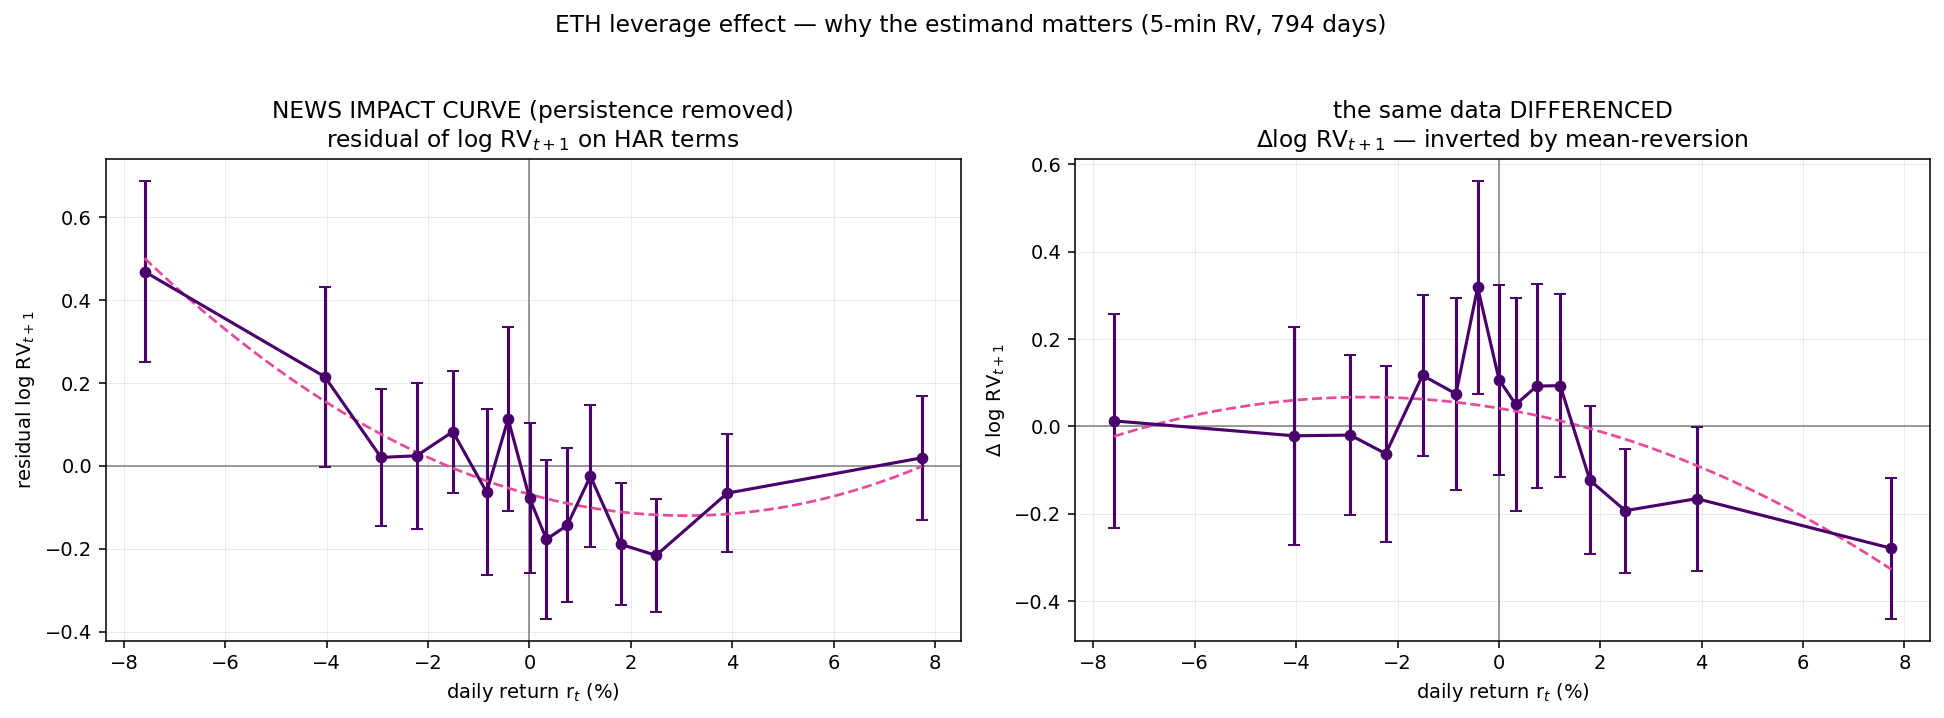

In [18]:
from IPython.display import Image, display
display(Image(str(RESULTS / "figures" / "leverage_shape.png")))

In [19]:
ht = LEV.horizon_term_structure(PERP, "5min")
ht[["n", "corr_clean", "corr_lo", "corr_hi", "sv_ratio", "sv_t"]].round(4)

,n,corr_clean,corr_lo,corr_hi,sv_ratio,sv_t
horizon,,,,,,
1h,19043,-0.0322,-0.0485,-0.0170,0.0073,2.2527
4h,4761,-0.0195,-0.0480,0.0092,0.0067,1.5021
12h,1587,-0.0072,-0.0425,0.0367,0.0059,1.0116
1D,794,-0.0851,-0.1491,-0.0162,-0.0025,-0.3583
3D,265,0.0594,-0.0383,0.1715,-0.0034,-0.4203
7D,114,0.0786,-0.0652,0.2062,-0.0098,-0.9647


**The effect peaks at the daily horizon and vanishes beyond it** — significant at 1h and
1D, indistinguishable from zero at 4h/12h, and positive (with CIs spanning zero) at 3D and
7D. **This is the opposite of equities**, where the leverage effect strengthens with
horizon. Worth flagging as a genuine difference rather than smoothing over.

### Robustness

In [20]:
print("Influence — is this a handful of liquidation cascades?")
display(LEV.influence_drop(daily).round(4))
print("\nPooled by CAUSAL regime (not the hand-labelled ones):")
display(LEV.by_regime(daily, reg_causal).round(4))

Influence — is this a handful of liquidation cascades?


,n,sv_ratio,sv_se,sv_t,corr_clean
sample,,,,,
all days,794,-0.0025,0.007,-0.3583,-0.0851
drop top 3 |r| days,791,-0.0025,0.007,-0.3629,-0.0874



Pooled by CAUSAL regime (not the hand-labelled ones):


,n,mean_rv_ann,sv_ratio,sv_se,sv_t,corr_clean,n_eff,boot_lo,boot_hi
regime,,,,,,,,,
drawdown,434,0.6567,-0.0036,0.0090,-0.3954,-0.1204,604.7080,-0.1982,-0.0405
near-high,96,0.6309,0.0735,0.0164,4.4876,-0.2060,67.2967,-0.4195,0.0303
neutral,264,0.5642,-0.0284,0.0125,-2.2732,0.0059,263.0000,-0.0993,0.1124


**Not cascade-driven:** dropping the 3 largest $|r|$ days moves the correlation from
−0.0851 to −0.0874. The October 2025 wicks do not carry the result.

**Regimes cannot be distinguished.** `near-high` reads −0.206 against `drawdown` −0.120,
but `near-high` has $n_{\text{eff}} = 67$ and a CI of $[-0.42, +0.03]$. 794 days with a
vol half-life of ~3 weeks contains perhaps **4–6 independent macro episodes**. There is
not enough independent variation to support a regime claim, and we do not make one.

**Multiple testing.** ~25 tests across estimators, horizons and regimes. Under Holm the
LHAR result ($p < 10^{-8}$) survives comfortably; the headline correlation ($p = 0.0059$)
**does not** survive family-wise correction on its own. The conclusion rests on the LHAR,
corroborated by the correlation and the news impact curve.

<a id="sec7"></a>
## 7. The volatility risk premium: nothing to harvest **[archive]**

This section needs the full options archive (`eth_hourly_2024.parquet`), which is on the
desk machine. Numbers are reported from the recorded runs of
`vrp_signal.py` / `regime_hmm.py` rather than recomputed here.

### 7a. The premium is zero

| quantity | value |
|---|---|
| mean ATM implied vol (30d constant maturity) | 62.9% |
| mean subsequent realised vol | 63.7% |
| **premium (IV − RV)** | **−0.82%** |
| t-statistic | **−0.44** |
| 95% CI | [−4.5%, +2.8%] vol points |

The premium is **negative, tiny, and indistinguishable from zero**. Options were, on
average, very slightly *cheap*. There is nothing to sell.

### 7b. The RV > IV signal has no predictive power

The natural rule — "enter when recent realised vol exceeds implied" — requires that
$RV_{\text{past}} - IV$ predicts $RV_{\text{future}} - IV$. It does not:

| statistic | value |
|---|---|
| correlation | +0.127 |
| t-statistic | 1.25 |
| $R^2$ | 1.6% |

ETH realised vol **is** persistent (weekly autocorrelation +0.27), so "vol has been high"
does predict "vol will be high". But implied vol already knows that — market makers see
the same history. The signal only has value if the market **under-reacts**, and it doesn't.

### 7c. The strategies traded direction, not volatility

| structure | β vs underlying | corr with spot |
|---|---|---|
| long call | +0.13 | +0.81 |
| short call | −0.13 | −0.80 |
| call-neutral structures | −0.03 | — |

Delta-hedging hourly removes delta. It does **not** remove vanna — the change in vega as
spot moves — so a call-exposed structure keeps a residual directional exposure. The
call-neutral structures are genuinely neutral (β = −0.03), which confirms the mechanism.

**This is where section 6 connects.** Vanna exposure is priced off the spot–vol
correlation, and we now know ETH's is only ≈ −0.21. A weak, unstable leverage effect gives
a thin, unstable vanna edge.

### 7d. Regime conditioning does not rescue it

An HMM on implied-vol-by-delta plus perp features separates low- and high-vol states
cleanly (77% persistence, 98.8% walk-forward accuracy on known states). **The premium is
zero in both states.** There is no regime in which selling vol worked.

<a id="sec8"></a>
## 8. Trials & errors

The honest version. Every one of these produced a plausible wrong answer rather than an
error.

1. **A parameter that changed units.** `rv_window` went from a bar count to calendar days.
   Same name, same call, and a measured correlation moved −0.02 → −0.18. **Lesson:** when
   a unit changes, rename the parameter.

2. **A correlation window too short to resolve the effect.** We ran `window_days=5` and
   read the resulting ±1 sawtooth as signal. At n=5 the smallest detectable $|\rho|$ is
   **0.88**; we were hunting 0.2.

3. **Interpreting an estimator before calibrating it.** Weeks spent reading a rolling
   correlation that Monte Carlo later showed to be attenuated 2.5× and, at n=90, unable to
   distinguish −0.2 from zero. **The simulation should have come first.**

4. **Trusting the "clean" estimand.** Signed variation was chosen precisely because it
   avoids a correlation coefficient — and it turns out to be blind to diffusive leverage,
   returning the *wrong sign* at ρ = −0.8. Elegance is not validity.

5. **A hindsight-labelled input.** `R.REGIMES` was hand-drawn peak-to-trough from the
   finished chart, and every regime statistic built on it was contaminated. Look-ahead
   arrives through the inputs you didn't think of as estimates.

6. **A library function that hijacked the backend.** `matplotlib.use("Agg")` inside a
   plotting helper switched the whole kernel headless, silently swallowing every figure in
   the notebook. Process-wide state does not belong in a library function.

7. **Throwing away 59/60ths of the data.** The pipeline aggregated 1-minute bars to hourly
   and sampled daily — 24 observations per RV estimate, 29% relative standard error, when
   1,440 were available at 3.7%. That noise attenuates every correlation for free.

<a id="sec9"></a>
## 9. Conclusion: a catalogue of well-measured zeros

**What is real:**

- **ETH has a negative leverage effect: ρ ≈ −0.21, CI [−0.37, −0.04].** Primary evidence
  LHAR $\gamma_d = -8.75$, $t = -5.76$, $p < 10^{-8}$. A −1% day raises next-day variance
  8.8% against 3.1% for a +1% day — down moves 2.8× more.
- **The discretisation loss is 3–6 vol points** for an hourly hedger on ETH, and it is
  state-dependent: near zero at 50% vol, ~15 points at the peaks.
- **The perp data is exceptionally clean** — zero missing minutes over 793.5 days.

**What is zero, measured carefully enough to say so:**

- The volatility risk premium: **−0.82%, t = −0.44**.
- The predictive power of RV > IV: $R^2$ **1.6%**, t = 1.25.
- Volatility feedback — vol shocks predicting returns: **nothing at any horizon** 1–10 days.
- Signed jump asymmetry: **−0.0025, p = 0.72**.
- Unconditional return skew: **+0.15** — ETH is *positively* skewed over this sample.
- Any difference in the leverage effect between regimes: **not distinguishable**, ~4–6
  independent episodes.

**What we cannot say from this data:**

- Whether options *price* the leverage effect correctly. That needs the implied side —
  $\partial\sigma_{ATM}/\partial\log F$, the skew-stickiness ratio, and the implied-versus-
  realised ρ gap, which is the skew risk premium. **This is the single highest-value
  remaining measurement**, and section 6 gives it a baseline to be compared against.
- Whether the leverage effect is stable out of sample. It peaks at the daily horizon,
  vanishes by 3 days, and behaves oppositely to equities. One 26-month sample is not
  enough to know if that is ETH or if it is 2024–2026.

**Next steps, in order of expected value:**

1. Build the constant-maturity, constant-moneyness IV surface and regress $\Delta IV$ on
   $\Delta\log F$. Compare the implied ρ to the −0.21 measured here.
2. Repeat the whole of section 6 on BTC. Two assets is not a panel, but a sign agreement
   would be worth more than another ETH robustness check.
3. Re-run the roll strategies with vanna hedged explicitly, now that the spot–vol
   correlation driving it is quantified.

---

> **The project's actual lesson.** Every wrong answer here came from an estimator that
> could not see what we were asking it about — a window in the wrong units, a sample too
> small to resolve the effect, a statistic structurally blind to the mechanism, a label
> that encoded the future. None announced itself. The Monte Carlo in section 5 is the only
> step that would have caught all four, and it is the cheapest cell in this notebook.

*End of summary.*